# Modelo de Ising con campo transverso: gráficas bajo diagonalización exacta

En este notebook usamos el Hamiltoniano

$$
H=-J\sum_{i=0}^{N-1}Z_iZ_{i+1}-h\sum_{i=0}^{N-1}X_i,
\qquad Z_N\equiv Z_0,
$$

por lo que la cadena es **cerrada** y tiene condiciones periódicas de frontera.

## Criterios usados para mejorar las gráficas

- Los tres observables se calculan durante **un solo barrido** de $h/J$; así evitamos diagonalizar tres veces el mismo Hamiltoniano.
- Las gráficas se colocan en una sola fila y comparten el eje horizontal, facilitando comparar qué ocurre alrededor de $h/J=1$.
- Se usa una línea vertical común para señalar el punto crítico del sistema infinito.
- Los marcadores se muestran solo cada ciertos puntos para evitar saturar la figura.
- Las condiciones de frontera se indican directamente en el título.
- Las funciones de cálculo quedan separadas de las funciones de visualización.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit.quantum_info import SparsePauliOp, Statevector

In [2]:
def hamiltoniano_ising_cerrado(
    J: float,
    h: float,
    n_q: int
) -> SparsePauliOp:
    r"""
    Hamiltoniano de Ising con campo transverso y frontera periódica:

        H = -J Σ_i Z_i Z_{i+1} - h Σ_i X_i,

    con Z_N = Z_0.
    """
    if n_q < 2:
        raise ValueError("n_q debe ser al menos 2.")

    terminos = []

    # Enlaces (0,1), (1,2), ..., (N-2,N-1), (N-1,0)
    for i in range(n_q):
        j = (i + 1) % n_q
        terminos.append(("ZZ", [i, j], -J))

    # Campo transversal
    for i in range(n_q):
        terminos.append(("X", [i], -h))

    return SparsePauliOp.from_sparse_list(
        terminos,
        num_qubits=n_q
    )


def estado_base_ising_cerrado(
    J: float,
    h: float,
    n_q: int,
    devolver_energia: bool = False
):
    """Obtiene el estado base por diagonalización exacta."""
    H = hamiltoniano_ising_cerrado(J=J, h=h, n_q=n_q)
    H_matrix = np.asarray(H.to_matrix(), dtype=complex)

    eigenvalues, eigenvectors = np.linalg.eigh(H_matrix)

    # Qiskit requiere en ocasiones un arreglo contiguo.
    vector_base = np.ascontiguousarray(
        eigenvectors[:, 0],
        dtype=complex
    )
    psi_0 = Statevector(vector_base)

    if devolver_energia:
        return float(np.real(eigenvalues[0])), psi_0

    return psi_0

In [3]:
def magnetizacion_z_cuadrada(n_q: int) -> SparsePauliOp:
    r"""
    M_z², donde M_z = (1/N) Σ_i Z_i.

    M_z² = I/N + (2/N²) Σ_{i<j} Z_i Z_j.
    """
    terminos = [("I" * n_q, 1.0 / n_q)]

    for i in range(n_q):
        for j in range(i + 1, n_q):
            pauli = ["I"] * n_q
            pauli[n_q - 1 - i] = "Z"
            pauli[n_q - 1 - j] = "Z"
            terminos.append(("".join(pauli), 2.0 / n_q**2))

    return SparsePauliOp.from_list(terminos)


def magnetizacion_x(n_q: int) -> SparsePauliOp:
    r"""M_x = (1/N) Σ_i X_i."""
    return SparsePauliOp.from_sparse_list(
        [("X", [i], 1.0 / n_q) for i in range(n_q)],
        num_qubits=n_q
    )


def correlacion_zz_vecinos_cerrada(n_q: int) -> SparsePauliOp:
    r"""
    C_zz = (1/N) Σ_i Z_i Z_{i+1}, con Z_N = Z_0.
    """
    terminos = [
        ("ZZ", [i, (i + 1) % n_q], 1.0 / n_q)
        for i in range(n_q)
    ]

    return SparsePauliOp.from_sparse_list(
        terminos,
        num_qubits=n_q
    )

In [4]:
def barrido_observables_ising_cerrado(
    n_q: int,
    J: float = 1.0,
    h_min: float = 0.0,
    h_max: float = 2.0,
    puntos: int = 101
):
    """
    Calcula los tres observables en un único barrido.

    Devuelve:
        h/J, <Mz²>, <Mx>, <Czz>, E0/N
    """
    if J == 0:
        raise ValueError("J no puede ser cero porque se grafica h/J.")
    if puntos < 2:
        raise ValueError("puntos debe ser al menos 2.")

    valores_h = np.linspace(h_min, h_max, puntos)

    Mz2 = magnetizacion_z_cuadrada(n_q)
    Mx = magnetizacion_x(n_q)
    Czz = correlacion_zz_vecinos_cerrada(n_q)

    valores_mz2 = np.empty(puntos)
    valores_mx = np.empty(puntos)
    valores_czz = np.empty(puntos)
    energias_por_sitio = np.empty(puntos)

    for k, h in enumerate(valores_h):
        energia_0, psi_0 = estado_base_ising_cerrado(
            J=J,
            h=h,
            n_q=n_q,
            devolver_energia=True
        )

        valores_mz2[k] = float(np.real_if_close(psi_0.expectation_value(Mz2)))
        valores_mx[k] = float(np.real_if_close(psi_0.expectation_value(Mx)))
        valores_czz[k] = float(np.real_if_close(psi_0.expectation_value(Czz)))
        energias_por_sitio[k] = energia_0 / n_q

    return {
        "h_sobre_J": valores_h / J,
        "mz2": valores_mz2,
        "mx": valores_mx,
        "czz": valores_czz,
        "energia_por_sitio": energias_por_sitio
    }

In [5]:
def graficar_observables_ising(
    resultados: dict,
    n_q: int,
    mostrar_energia: bool = False
):
    """Presenta los observables en paneles comparables."""
    x = resultados["h_sobre_J"]

    observables = [
        (resultados["mz2"], r"$\langle M_z^2\rangle$", "Orden longitudinal"),
        (resultados["mx"], r"$\langle M_x\rangle$", "Magnetización transversal"),
        (resultados["czz"], r"$\langle C_{zz}\rangle$", "Correlación entre vecinos")
    ]

    if mostrar_energia:
        observables.append((
            resultados["energia_por_sitio"],
            r"$E_0/N$",
            "Energía base por sitio"
        ))

    n_paneles = len(observables)
    fig, axes = plt.subplots(
        1,
        n_paneles,
        figsize=(5.2 * n_paneles, 4.5),
        sharex=True
    )

    if n_paneles == 1:
        axes = [axes]

    # Reduce la saturación de marcadores sin perder los puntos calculados.
    markevery = max(1, len(x) // 20)

    for ax, (y, ylabel, titulo) in zip(axes, observables):
        ax.plot(
            x,
            y,
            linewidth=2,
            marker="o",
            markersize=4,
            markevery=markevery,
            label=rf"$N={n_q}$"
        )
        ax.axvline(
            1.0,
            linestyle="--",
            linewidth=1.5,
            label=r"$h/J=1$"
        )
        ax.set_title(titulo)
        ax.set_xlabel(r"$h/J$")
        ax.set_ylabel(ylabel)
        ax.set_xlim(x.min(), x.max())
        ax.grid(alpha=0.25)
        ax.legend(frameon=False)

    # Los tres observables son adimensionales y están naturalmente entre 0 y 1.
    for ax in axes[:3]:
        ax.set_ylim(-0.03, 1.03)

    fig.suptitle(
        "Modelo de Ising con campo transverso — cadena cerrada\n"
        rf"Diagonalización exacta, $N={n_q}$",
        fontsize=14
    )
    fig.tight_layout(rect=(0, 0, 1, 0.90))
    plt.show()

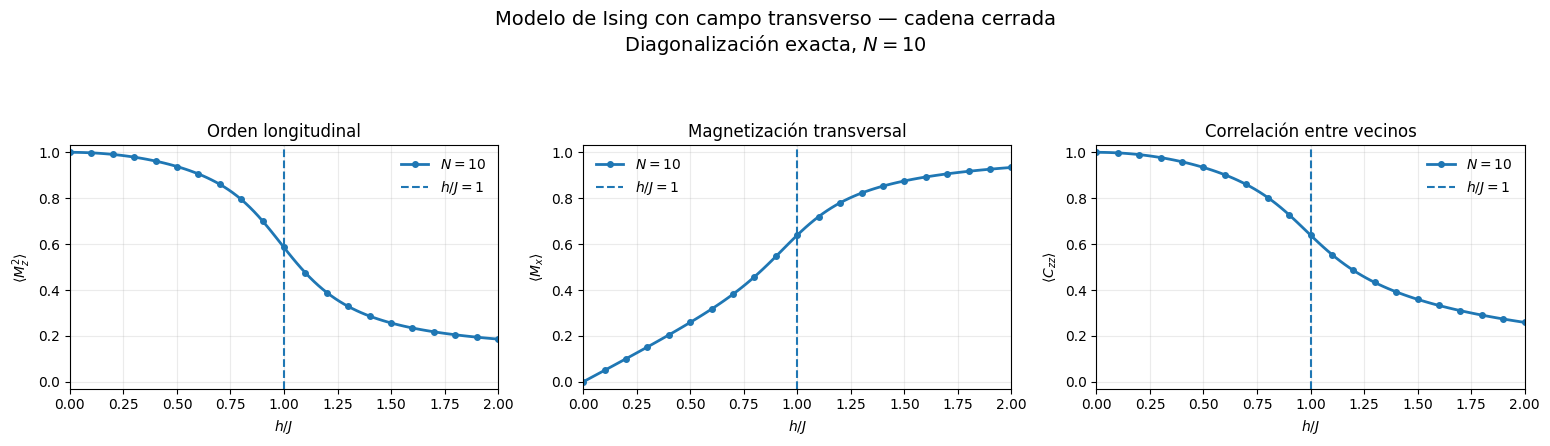

In [6]:
# Parámetros principales
N_QUBITS = 10
PUNTOS = 101

resultados = barrido_observables_ising_cerrado(
    n_q=N_QUBITS,
    J=1.0,
    h_min=0.0,
    h_max=2.0,
    puntos=PUNTOS
)

graficar_observables_ising(
    resultados=resultados,
    n_q=N_QUBITS,
    mostrar_energia=False
)

## Cómo leer las curvas

- Para $h/J\ll1$, domina el acoplamiento $ZZ$: se espera una magnetización longitudinal cuadrática y una correlación $ZZ$ grandes.
- Para $h/J\gg1$, domina el campo transversal: $\langle M_x\rangle$ se acerca a uno.
- Cerca de $h/J\approx1$, las curvas cambian rápidamente. Para un sistema finito no aparece una discontinuidad perfecta, sino una transición suavizada.
- Al usar una cadena cerrada, todos los qubits tienen el mismo número de vecinos y se reducen los efectos artificiales de los extremos.

## Comparar distintos tamaños del sistema

Esta gráfica adicional es útil para observar cómo la transición se vuelve más pronunciada al aumentar $N$. Como la diagonalización exacta usa matrices de tamaño $2^N\times2^N$, el costo crece exponencialmente.

In [7]:
def comparar_tamanos_mz2(
    tamanos=(4, 6, 8),
    puntos: int = 81
):
    plt.figure(figsize=(8, 5))

    for n_q in tamanos:
        datos = barrido_observables_ising_cerrado(
            n_q=n_q,
            J=1.0,
            h_min=0.0,
            h_max=2.0,
            puntos=puntos
        )

        plt.plot(
            datos["h_sobre_J"],
            datos["mz2"],
            linewidth=2,
            label=rf"$N={n_q}$"
        )

    plt.axvline(1.0, linestyle="--", linewidth=1.5, label=r"$h/J=1$")
    plt.xlabel(r"$h/J$")
    plt.ylabel(r"$\langle M_z^2\rangle$")
    plt.title("Efecto del tamaño del sistema — cadena cerrada")
    plt.xlim(0, 2)
    plt.ylim(-0.03, 1.03)
    plt.grid(alpha=0.25)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


# Descomenta para comparar tamaños:
# comparar_tamanos_mz2(tamanos=(4, 6, 8), puntos=81)